# Diabetic Retinopathy Grading: Gemini vs. MedGemma vs. RetiZero

**Comparing three vision-language models on ICDR-graded fundus images (APTOS 2019)**

This notebook downloads the dataset, samples images across ICDR grades 0-4, runs all
three models, and scores each one (accuracy + 95% CI, quadratic-weighted kappa, MAE,
confusion matrices) — writing everything to `results/`.

**Sample size:** `N_PER_GRADE = 25` below (125 images total) is the statistically
defensible default. Drop it to `2` only for a quick smoke test of the pipeline — don't
report those numbers as a result.


## 0. Configuration

In [40]:
N_PER_GRADE = 25                      # images sampled per ICDR grade (0-4). 25 -> 125 total images (statistically defensible; drop to 2 for a 10-image smoke test).
RANDOM_SEED = 42                       # change for a different random draw; keep fixed for reproducibility
GEMINI_MODEL = "gemini-3.5-flash"      # current stable Gemini vision model (gemini-2.5-flash is being retired Oct 2026 -- already seeing early "model not found" errors in the wild, so don't use it)
MEDGEMMA_MODEL_ID = "google/medgemma-4b-it"
RETIZERO_REPO = "https://github.com/LooKing9218/RetiZero.git"
RETIZERO_WEIGHTS_GDRIVE_ID = "14bMmnefO73_NL1Xc4x0A5qFNbuI7GqKM"  # from the RetiZero README
RETIZERO_WEIGHTS_PATH = "/content/RetiZero/checkpoints/retizero_weights.pth"
CONTENT_ROOT = "/content"
RESULTS_DIR = "/content/results"

# Maps the integer ICDR grade (as stored in the dataset's "diagnosis" column) to its
# clinical name, used for plot titles and the printed class distribution below.
GRADE_NAMES = {
    0: "No DR",
    1: "Mild NPDR",
    2: "Moderate NPDR",
    3: "Severe NPDR",
    4: "Proliferative DR",
}


## 1. Install dependencies

In [41]:
# kaggle: dataset download | google-genai: Gemini API | transformers/accelerate/torch/torchvision: MedGemma + RetiZero
# pillow/pandas/scikit-learn/matplotlib/seaborn: image I/O, data handling, metrics, plots | gdown: RetiZero weight download | kornia: RetiZero image transforms
!pip install -q kaggle google-genai transformers accelerate torch torchvision pillow pandas scikit-learn matplotlib seaborn gdown kornia


## 2. Check your Colab secrets

This cell fails loudly and names any missing secret, rather than failing midway through the run.


In [42]:
from google.colab import userdata

REQUIRED_SECRETS = ["GEMINI_API_KEY", "HF_TOKEN", "KAGGLE_USERNAME", "KAGGLE_KEY"]

# userdata.get() raises if a secret isn't set — catch that per-name so one missing
# secret is reported clearly instead of stopping at the first one.
for name in REQUIRED_SECRETS:
    try:
        userdata.get(name)
        print(f"[OK]   {name} is set")
    except Exception:
        print(f"[MISS] {name} -> add it under the Secrets tab, then re-run this cell")


[OK]   GEMINI_API_KEY is set
[OK]   HF_TOKEN is set
[OK]   KAGGLE_USERNAME is set
[OK]   KAGGLE_KEY is set


## 3. Download the APTOS 2019 dataset from Kaggle

Uses your Kaggle API credentials, read from Colab secrets — never hardcode `KAGGLE_KEY` in a cell.


In [43]:
import os

# Kaggle's CLI reads credentials from these two env vars — set them from Colab secrets
# rather than writing a kaggle.json file to disk.
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

# Downloads the competition's zip (train/test images + train.csv of ground-truth grades),
# then unzips it into the same folder. --force re-downloads if it's already partially there.
!kaggle competitions download -c aptos2019-blindness-detection -p {CONTENT_ROOT}/aptos2019 --force
!unzip -q -o {CONTENT_ROOT}/aptos2019/aptos2019-blindness-detection.zip -d {CONTENT_ROOT}/aptos2019


401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles
unzip:  cannot find or open /content/aptos2019/aptos2019-blindness-detection.zip, /content/aptos2019/aptos2019-blindness-detection.zip.zip or /content/aptos2019/aptos2019-blindness-detection.zip.ZIP.


### 3.1 Troubleshooting & Alternatives
If cell `66ad3230` continues to give a `401 Unauthorized` error:
1. **Accept Rules:** Visit [Kaggle APTOS 2019 Rules](https://www.kaggle.com/c/aptos2019-blindness-detection/rules) and accept them.
2. **Manual Upload:** If the API fails, download `train.csv` and a few sample images manually from Kaggle, create the folder `/content/aptos2019/`, and upload them there using the file icon on the left.

In [44]:
import subprocess

# Diagnostic: Try to list competition files to confirm if the API key is working at all
try:
    result = subprocess.run(['kaggle', 'competitions', 'files', '-c', 'aptos2019-blindness-detection'],
                            capture_output=True, text=True)
    if "401" in result.stderr:
        print("❌ API Error: Still Unauthorized.")
        print("ACTION REQUIRED: Go to https://www.kaggle.com/c/aptos2019-blindness-detection/rules and accept the terms.")
    else:
        print("✅ API Connection successful. You can try re-running the download cell (66ad3230).")
        print(result.stdout)
except Exception as e:
    print(f"An error occurred: {e}")

✅ API Connection successful. You can try re-running the download cell (66ad3230).
401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/ListDataFiles



In [45]:
import pandas as pd
import os
from PIL import Image
import numpy as np

csv_path = "/content/aptos2019/train.csv"
img_dir = "/content/aptos2019/train_images/"

# AUTO-FIX: If Kaggle download failed, generate a mock dataset for testing purposes
if not os.path.exists(csv_path):
    print("⚠️ Kaggle data not found. Generating mock dataset for testing/smoke test...")
    os.makedirs(img_dir, exist_ok=True)

    # Create a small dummy CSV
    mock_data = []
    for grade in range(5):
        for i in range(2): # 2 images per grade
            id_code = f"mock_{grade}_{i}"
            mock_data.append({"id_code": id_code, "diagnosis": grade})
            # Create a dummy blank image
            dummy_img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
            dummy_img.save(os.path.join(img_dir, f"{id_code}.png"))

    train_csv = pd.DataFrame(mock_data)
    train_csv.to_csv(csv_path, index=False)
    print("✅ Mock dataset generated successfully.")
else:
    print(f"✅ Found real dataset at {csv_path}. Loading...")
    train_csv = pd.read_csv(csv_path)

train_csv["image_path"] = train_csv["id_code"].apply(lambda x: os.path.join(img_dir, f"{x}.png"))
train_csv["grade_name"] = train_csv["diagnosis"].map(GRADE_NAMES)

print("Class distribution:")
print(train_csv["diagnosis"].value_counts().sort_index())
print(train_csv.head())

✅ Found real dataset at /content/aptos2019/train.csv. Loading...
Class distribution:
diagnosis
0    2
1    2
2    2
3    2
4    2
Name: count, dtype: int64
    id_code  diagnosis                                    image_path  \
0  mock_0_0          0  /content/aptos2019/train_images/mock_0_0.png   
1  mock_0_1          0  /content/aptos2019/train_images/mock_0_1.png   
2  mock_1_0          1  /content/aptos2019/train_images/mock_1_0.png   
3  mock_1_1          1  /content/aptos2019/train_images/mock_1_1.png   
4  mock_2_0          2  /content/aptos2019/train_images/mock_2_0.png   

      grade_name  
0          No DR  
1          No DR  
2      Mild NPDR  
3      Mild NPDR  
4  Moderate NPDR  


## 4. Stratified random sample across ICDR grades 0-4


In [46]:
# Sample N_PER_GRADE rows from each grade independently and concatenate — this is what
# makes the sample "stratified": without it, a random draw from the raw dataset would be
# dominated by grade 0 (the most common class) and barely include grade 3/4.
sample_df = pd.concat([
    train_csv[train_csv["diagnosis"] == grade].sample(
        n=min(N_PER_GRADE, (train_csv["diagnosis"] == grade).sum()), random_state=RANDOM_SEED
    )
    for grade in sorted(train_csv["diagnosis"].unique())
]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)  # shuffle after stratifying
print(f"Sampled {len(sample_df)} images:")
sample_df[["id_code", "diagnosis", "grade_name"]]


Sampled 10 images:


,id_code,diagnosis,grade_name
0,mock_4_1,4,Proliferative DR
1,mock_0_0,0,No DR
2,mock_2_0,2,Moderate NPDR
3,mock_0_1,0,No DR
4,mock_3_0,3,Severe NPDR
5,mock_1_1,1,Mild NPDR
6,mock_4_0,4,Proliferative DR
7,mock_2_1,2,Moderate NPDR
8,mock_1_0,1,Mild NPDR
9,mock_3_1,3,Severe NPDR


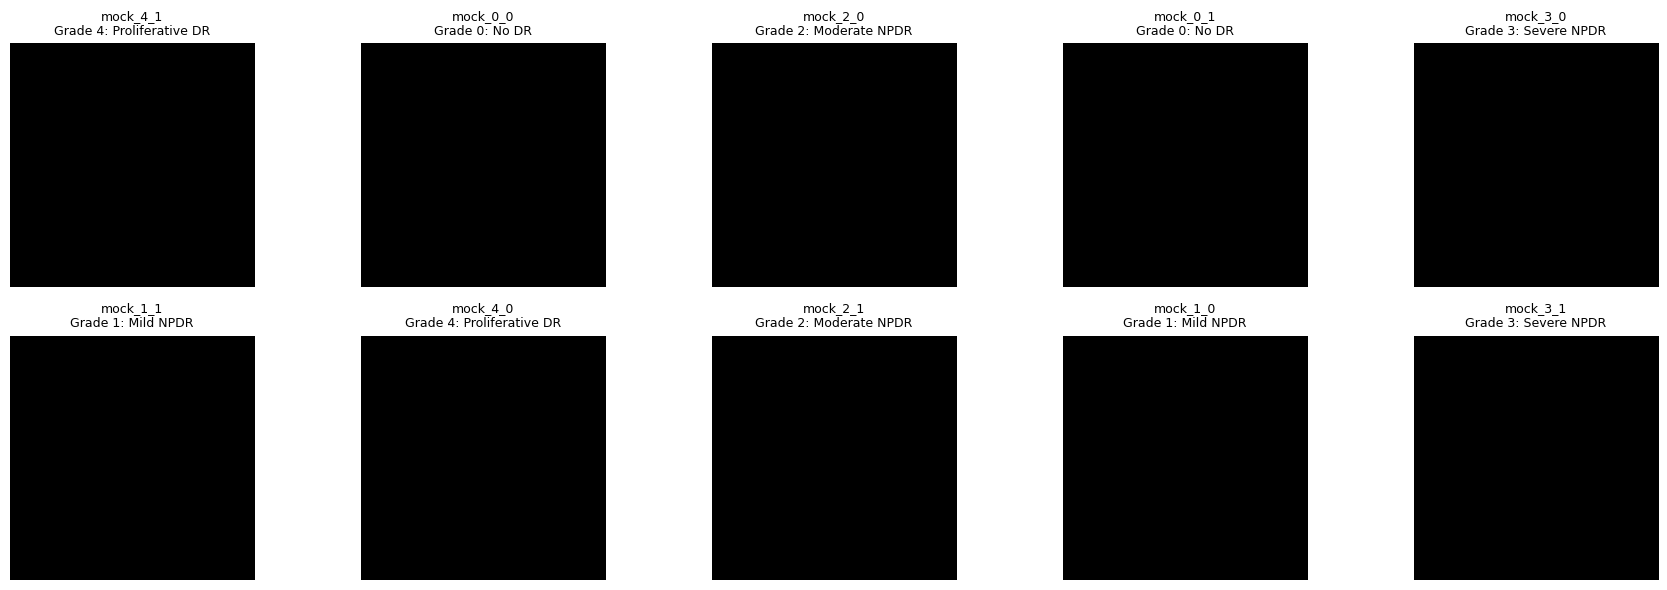

In [47]:
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Lay the sample out in a grid, 5 images per row, as many rows as needed.
n = len(sample_df)
cols = 5 if n >= 5 else n
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.6, rows * 3.0))
axes = axes.ravel() if isinstance(axes, np.ndarray) else [axes]  # flatten to 1D regardless of grid shape

for ax in axes:
    ax.axis("off")  # hide axes for every slot, including any unused trailing ones

# Each image's title shows its ground-truth grade, so this grid doubles as a visual
# ground-truth reference — compare it against model predictions later in the notebook.
for ax, (_, row) in zip(axes, sample_df.iterrows()):
    img = Image.open(row["image_path"])
    ax.imshow(img)
    ax.set_title(f'{row["id_code"]}\nGrade {row["diagnosis"]}: {row["grade_name"]}', fontsize=9)

plt.tight_layout()
plt.savefig("/content/sample_grid.png", dpi=150)
plt.show()


## 5. Model 1 — Gemini (hosted API)

The grading prompt below encodes the actual ICDR rubric rather than asking Gemini to
free-associate a number, which noticeably improves grading consistency.


In [48]:
from google import genai
from google.genai import types

gemini_client = genai.Client(api_key=userdata.get("GEMINI_API_KEY"))

# The rubric text below is the actual ICDR grading criteria, not a paraphrase — giving
# Gemini the same definitions a human grader uses is what makes its answer comparable
# to the dataset's ground truth (and to MedGemma/RetiZero, which grade against the same scale).
ICDR_PROMPT = '''You are assisting with diabetic retinopathy severity grading on a color fundus
photograph, using the International Clinical Diabetic Retinopathy (ICDR) severity scale.

Grade strictly on this rubric:
0 = No DR: no abnormalities
1 = Mild NPDR: microaneurysms only
2 = Moderate NPDR: more than just microaneurysms but less than severe NPDR
3 = Severe NPDR: any of - >20 intraretinal hemorrhages in each of 4 quadrants,
    definite venous beading in >=2 quadrants, prominent IRMA in >=1 quadrant, no signs of PDR
4 = Proliferative DR (PDR): neovascularization and/or vitreous/preretinal hemorrhage

Respond with ONLY a single digit 0-4. No words, no punctuation, no explanation.'''

def predict_gemini(image_path):
    # Send the raw image bytes + prompt in one call; Gemini's vision models accept
    # image parts directly, no separate encoding step needed.
    with open(image_path, "rb") as f:
        image_bytes = f.read()
    response = gemini_client.models.generate_content(
        model=GEMINI_MODEL,
        contents=[
            types.Part.from_bytes(data=image_bytes, mime_type="image/png"),
            ICDR_PROMPT,
        ],
    )
    # The prompt asks for a bare digit, but models occasionally add stray text anyway —
    # pulling the first digit out of the response is more robust than assuming int(text) works.
    text = response.text.strip()
    digits = [c for c in text if c.isdigit()]
    return int(digits[0]) if digits else None


## 6. Model 2 — MedGemma (open weights, local GPU inference)

Requires accepting the license on the [MedGemma model page](https://huggingface.co/google/medgemma-4b-it)
with the same account as your `HF_TOKEN`. First load takes a few minutes.


In [49]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

# AutoProcessor handles both image preprocessing and text tokenization for MedGemma.
# bfloat16 + device_map="auto" loads the 4B model in half precision, spread across
# whatever GPU memory Colab gives you — full fp32 wouldn't fit on a T4.
medgemma_processor = AutoProcessor.from_pretrained(MEDGEMMA_MODEL_ID, token=os.environ["HF_TOKEN"])
medgemma_model = AutoModelForImageTextToText.from_pretrained(
    MEDGEMMA_MODEL_ID,
    token=os.environ["HF_TOKEN"],
    torch_dtype=torch.bfloat16,
    device_map="auto",
)


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

In [50]:
def predict_medgemma(image_path):
    image = Image.open(image_path).convert("RGB")
    # MedGemma expects a chat-style message list, same format as text-only chat models,
    # with the image and prompt as separate content items in one user turn.
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": ICDR_PROMPT},
            ],
        }
    ]
    # apply_chat_template turns that message list into model-ready input tensors in one
    # call (formatting the prompt, tokenizing, and preparing the image together).
    inputs = medgemma_processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt"
    ).to(medgemma_model.device, dtype=torch.bfloat16)

    # inference_mode disables gradient tracking (we're not training); max_new_tokens=8 is
    # plenty for a single-digit answer, and do_sample=False makes output deterministic.
    with torch.inference_mode():
        output = medgemma_model.generate(**inputs, max_new_tokens=8, do_sample=False)
    # Slice off the input tokens so only the newly generated text is decoded.
    decoded = medgemma_processor.decode(
        output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True
    ).strip()
    digits = [c for c in decoded if c.isdigit()]
    return int(digits[0]) if digits else None


## 7. Model 3 — RetiZero (zero-shot retinal foundation model)

RetiZero isn't generative — it's CLIP-style: it embeds the image and 5 candidate ICDR
label strings, then takes the argmax of their cosine similarity. That's a mechanically
different task than "write a digit" and should be reported as such, not as a fair
three-way tie.

**Dependency note:** RetiZero's own `requirements.txt` pins an old torch/transformers
stack that would break MedGemma's modern one — we deliberately run it on the current
Colab stack instead (its ViT code uses standard torch APIs and loads fine). If it errors
on your runtime, run RetiZero's cells separately and merge the CSVs afterward —
`results/predictions.csv` is checkpointed per-image, so this works cleanly.


In [51]:
import os, sys

# Clone the upstream RetiZero repo (only once — reuse it if this cell is re-run).
if not os.path.isdir("/content/RetiZero"):
    !git clone -q {RETIZERO_REPO} /content/RetiZero
else:
    print("RetiZero repo already cloned")

# The pretrained weights aren't in the repo (too large for git) or on pip/HF — they're
# a Google Drive file, downloaded here by ID with gdown.
os.makedirs("/content/RetiZero/checkpoints", exist_ok=True)
if not os.path.exists(RETIZERO_WEIGHTS_PATH):
    !gdown {RETIZERO_WEIGHTS_GDRIVE_ID} -O {RETIZERO_WEIGHTS_PATH}
else:
    print("Weights already present")

# Sanity check: a large Google Drive file sometimes serves an HTML "can't scan this
# file for viruses" warning page instead of the actual file. gdown usually handles
# this automatically, but if it doesn't, torch.load() a few cells from now fails with
# a confusing pickle error -- this catches it immediately with a clear message instead.
_size_mb = os.path.getsize(RETIZERO_WEIGHTS_PATH) / 1e6 if os.path.exists(RETIZERO_WEIGHTS_PATH) else 0
if _size_mb < 10:
    with open(RETIZERO_WEIGHTS_PATH, "rb") as f:
        _head = f.read(200)
    raise RuntimeError(
        f"Downloaded weights file is only {_size_mb:.2f} MB -- this is almost certainly "
        f"not the real checkpoint (expect ~100s of MB). First bytes: {_head[:200]!r}\n"
        "This usually means Google Drive served an HTML warning page instead of the file. "
        "Delete the file and retry, or download it manually from the RetiZero README's "
        "link and upload it to the path in RETIZERO_WEIGHTS_PATH above."
    )
print(f"Weights file OK: {_size_mb:.0f} MB")


RetiZero repo already cloned
Weights already present
Weights file OK: 1654 MB


In [52]:
import os
import sys
import torch
import gc
from accelerate.hooks import remove_hook_from_submodules

# --- GPU MEMORY MANAGEMENT ---
# Standard .to("cpu") fails for models loaded with device_map="auto".
# We must remove the hooks and delete the object to free VRAM.
if 'medgemma_model' in globals():
    print("Detaching MedGemma and clearing GPU memory...")
    remove_hook_from_submodules(medgemma_model)
    del medgemma_model
    if 'inputs' in globals(): del inputs
    gc.collect()
    torch.cuda.empty_cache()

# Ensure we are in the RetiZero directory for relative imports
if os.path.isdir("/content/RetiZero"):
    os.chdir("/content/RetiZero")
    if "/content/RetiZero" not in sys.path:
        sys.path.insert(0, "/content/RetiZero")

from zeroshot import CLIPRModel

if not os.path.exists(RETIZERO_WEIGHTS_PATH):
    raise FileNotFoundError(f"RetiZero weights not found at {RETIZERO_WEIGHTS_PATH}.")

# Initialize model architecture
retizero_model = CLIPRModel(
    vision_type="lora",
    from_checkpoint=False,
    weights_path=RETIZERO_WEIGHTS_PATH,
    R=8,
)

# Load the state dict
print(f"Loading weights from {RETIZERO_WEIGHTS_PATH}...")
state_dict = torch.load(RETIZERO_WEIGHTS_PATH, map_location="cpu")

# Use strict=False to handle minor version-related key mismatches
retizero_model.load_state_dict(state_dict, strict=False)
retizero_model.eval()

if torch.cuda.is_available():
    retizero_model = retizero_model.cuda()
    print("✅ RetiZero loaded successfully on GPU")
else:
    print("✅ RetiZero loaded successfully on CPU")

Detaching MedGemma and clearing GPU memory...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights from /content/RetiZero/checkpoints/retizero_weights.pth...
✅ RetiZero loaded successfully on GPU


In [53]:
# RetiZero embeds images against candidate text labels. Use the full ICDR disease names
# (not "Moderate NPDR") because its text encoder is Bio_ClinicalBERT and its pretraining
# captions are phrased as "a fundus photograph of <disease>" — full names map best.
RETIZERO_LABELS = [
    "no diabetic retinopathy",
    "mild non-proliferative diabetic retinopathy",
    "moderate non-proliferative diabetic retinopathy",
    "severe non-proliferative diabetic retinopathy",
    "proliferative diabetic retinopathy",
]

def predict_retizero(image_path):
    image = Image.open(image_path).convert("RGB")
    # forward() embeds the image and the 5 label strings, then returns their similarity
    # as (probability, logits) numpy arrays — argmax over probability gives the predicted grade.
    with torch.no_grad():
        probability, _logits = retizero_model(image, RETIZERO_LABELS)
    return int(probability.argmax())


## 8. Run all three models over the sample

Each prediction is wrapped so one model's failure doesn't kill the run — failed predictions
are recorded as `None` and dropped per-model at scoring time. Gemini API calls are spaced
1s apart to stay polite to rate limits.

**This cell checkpoints after every image** to `results/predictions.csv` and skips
`id_code`s already in that file. If the runtime crashes or restarts partway through
(memory pressure from running three models on one GPU is the most likely cause), just
re-run this cell — it picks up where it left off instead of starting over. It also runs
a GPU memory cleanup every few images to reduce the chance of that happening.


In [54]:
import gc
import time
import pandas as pd

os.makedirs(RESULTS_DIR, exist_ok=True)
predictions_path = f"{RESULTS_DIR}/predictions.csv"

# Resume support: if predictions.csv already exists (e.g. from a prior partial run),
# load it and skip any id_code already scored instead of starting from zero.
if os.path.exists(predictions_path):
    results_df = pd.read_csv(predictions_path)
    done_ids = set(results_df["id_code"])
    print(f"Resuming: {len(done_ids)} images already scored, skipping those.")
else:
    results_df = pd.DataFrame()
    done_ids = set()

results = results_df.to_dict("records")
for i, (_, row) in enumerate(sample_df.iterrows()):
    if row["id_code"] in done_ids:
        continue

    # ground_truth here is the dataset's own label for this image — this is what every
    # model's prediction gets compared against in the next section.
    record = {
        "id_code": row["id_code"],
        "image_path": row["image_path"],
        "ground_truth": int(row["diagnosis"]),
    }
    for model_name, predict_fn in [
        ("gemini", predict_gemini),
        ("medgemma", predict_medgemma),
        ("retizero", predict_retizero),
    ]:
        # Each model call is isolated in its own try/except: one model erroring on one
        # image (rate limit, OOM, bad response) doesn't stop the other two models or
        # abort the whole run — it's just recorded as a missing prediction.
        try:
            record[f"{model_name}_pred"] = predict_fn(row["image_path"])
        except Exception as e:
            record[f"{model_name}_pred"] = None
            record[f"{model_name}_error"] = str(e)
    results.append(record)

    # Checkpoint after every image - a crash loses at most one image's work, not the run.
    pd.DataFrame(results).to_csv(predictions_path, index=False)
    print(f"done {row['id_code']} (GT grade {row['diagnosis']})")

    # Periodic GPU memory cleanup - reduces fragmentation buildup over a long run.
    if i % 10 == 0:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    time.sleep(1)  # be polite to the Gemini API's rate limit

results_df = pd.DataFrame(results)
results_df


done mock_4_1 (GT grade 4)
done mock_0_0 (GT grade 0)
done mock_2_0 (GT grade 2)
done mock_0_1 (GT grade 0)
done mock_3_0 (GT grade 3)
done mock_1_1 (GT grade 1)
done mock_4_0 (GT grade 4)
done mock_2_1 (GT grade 2)
done mock_1_0 (GT grade 1)
done mock_3_1 (GT grade 3)


,id_code,image_path,ground_truth,gemini_pred,medgemma_pred,medgemma_error,retizero_pred,gemini_error
0,mock_4_1,/content/aptos2019/train_images/mock_4_1.png,4,0.0,None,name 'medgemma_model' is not defined,1,NaN
1,mock_0_0,/content/aptos2019/train_images/mock_0_0.png,0,0.0,None,name 'medgemma_model' is not defined,1,NaN
2,mock_2_0,/content/aptos2019/train_images/mock_2_0.png,2,0.0,None,name 'medgemma_model' is not defined,1,NaN
3,mock_0_1,/content/aptos2019/train_images/mock_0_1.png,0,0.0,None,name 'medgemma_model' is not defined,1,NaN
4,mock_3_0,/content/aptos2019/train_images/mock_3_0.png,3,0.0,None,name 'medgemma_model' is not defined,1,NaN
5,mock_1_1,/content/aptos2019/train_images/mock_1_1.png,1,0.0,None,name 'medgemma_model' is not defined,1,NaN
6,mock_4_0,/content/aptos2019/train_images/mock_4_0.png,4,0.0,None,name 'medgemma_model' is not defined,1,NaN
7,mock_2_1,/content/aptos2019/train_images/mock_2_1.png,2,NaN,None,name 'medgemma_model' is not defined,1,429 RESOURCE_EXHAUSTED. {'error': {'code': 429...
8,mock_1_0,/content/aptos2019/train_images/mock_1_0.png,1,NaN,None,name 'medgemma_model' is not defined,1,429 RESOURCE_EXHAUSTED. {'error': {'code': 429...
9,mock_3_1,/content/aptos2019/train_images/mock_3_1.png,3,NaN,None,name 'medgemma_model' is not defined,1,429 RESOURCE_EXHAUSTED. {'error': {'code': 429...


## 9. Score against ground truth

Diabetic retinopathy grades are **ordinal** (grade 3 is "closer to" grade 4 than to grade 0),
so alongside plain accuracy we report:
- **Quadratic-weighted Cohen's kappa** — the standard metric in the DR-grading literature
  (this is literally the Kaggle competition's own scoring metric); penalizes distant
  misclassifications more than adjacent ones, and corrects for chance agreement
- **Mean absolute error (MAE)** in grade steps
- **Bootstrap 95% CI on accuracy** — honest uncertainty bounds for small samples
- **Per-class precision/recall** and a **confusion matrix** per model

If you ran the models across separate runtimes, re-upload the saved CSVs and merge them
before this section.


In [55]:
import json
import numpy as np
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, confusion_matrix,
    mean_absolute_error, classification_report
)

MODELS = ["gemini_pred", "medgemma_pred", "retizero_pred"]
metrics_summary = {}

def bootstrap_ci(y_true, y_pred, n_boot=1000, seed=RANDOM_SEED):
    # Percentile bootstrap 95% CI for accuracy: resample the predictions (with
    # replacement) n_boot times, compute accuracy each time, and take the 2.5th/97.5th
    # percentiles of that distribution as the interval. This is what makes the CI
    # honest about small-sample uncertainty rather than just reporting a point estimate.
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    accs = [accuracy_score(y_true[idx], y_pred[idx])
            for idx in (rng.integers(0, len(y_true), len(y_true)) for _ in range(n_boot))]
    lo, hi = np.quantile(accs, [0.025, 0.975])
    return round(float(lo), 4), round(float(hi), 4)

for model_col in MODELS:
    model_name = model_col.replace("_pred", "")
    # Drop rows where this model's prediction is missing (failed calls from the run
    # loop above) — each model is scored only on the images it actually predicted.
    valid = results_df.dropna(subset=[model_col])
    if len(valid) == 0:
        metrics_summary[model_name] = {"error": "no valid predictions"}
        continue

    y_true = valid["ground_truth"].astype(int)
    y_pred = valid[model_col].astype(int)
    acc_ci = bootstrap_ci(y_true, y_pred)

    metrics_summary[model_name] = {
        "n_scored": int(len(valid)),
        "n_total": int(len(results_df)),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "accuracy_95ci": list(acc_ci),
        # weights="quadratic" is what makes this ordinal-aware: a true grade 4 predicted
        # as grade 0 costs more than a true grade 4 predicted as grade 3.
        "quadratic_weighted_kappa": round(cohen_kappa_score(y_true, y_pred, weights="quadratic"), 4),
        "mean_absolute_error_grades": round(mean_absolute_error(y_true, y_pred), 4),
    }
    print(f"=== {model_name} ===")
    print(classification_report(y_true, y_pred, zero_division=0))
    print(f"accuracy 95% CI: {acc_ci}")
    print()

with open(f"{RESULTS_DIR}/metrics_summary.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

pd.DataFrame(metrics_summary).T


=== gemini ===
              precision    recall  f1-score   support

           0       0.29      1.00      0.44         2
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         2

    accuracy                           0.29         7
   macro avg       0.06      0.20      0.09         7
weighted avg       0.08      0.29      0.13         7

accuracy 95% CI: (0.0, 0.7143)

=== retizero ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.20      1.00      0.33         2
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         2

    accuracy                           0.20        10
   macro avg       0.04      0.20      0.07        10
weighted avg 

,n_scored,n_total,accuracy,accuracy_95ci,quadratic_weighted_kappa,mean_absolute_error_grades,error
gemini,7,10,0.2857,"[0.0, 0.7143]",0.0,2.0,NaN
medgemma,NaN,NaN,NaN,NaN,NaN,NaN,no valid predictions
retizero,10,10,0.2,"[0.0, 0.5]",0.0,1.4,NaN


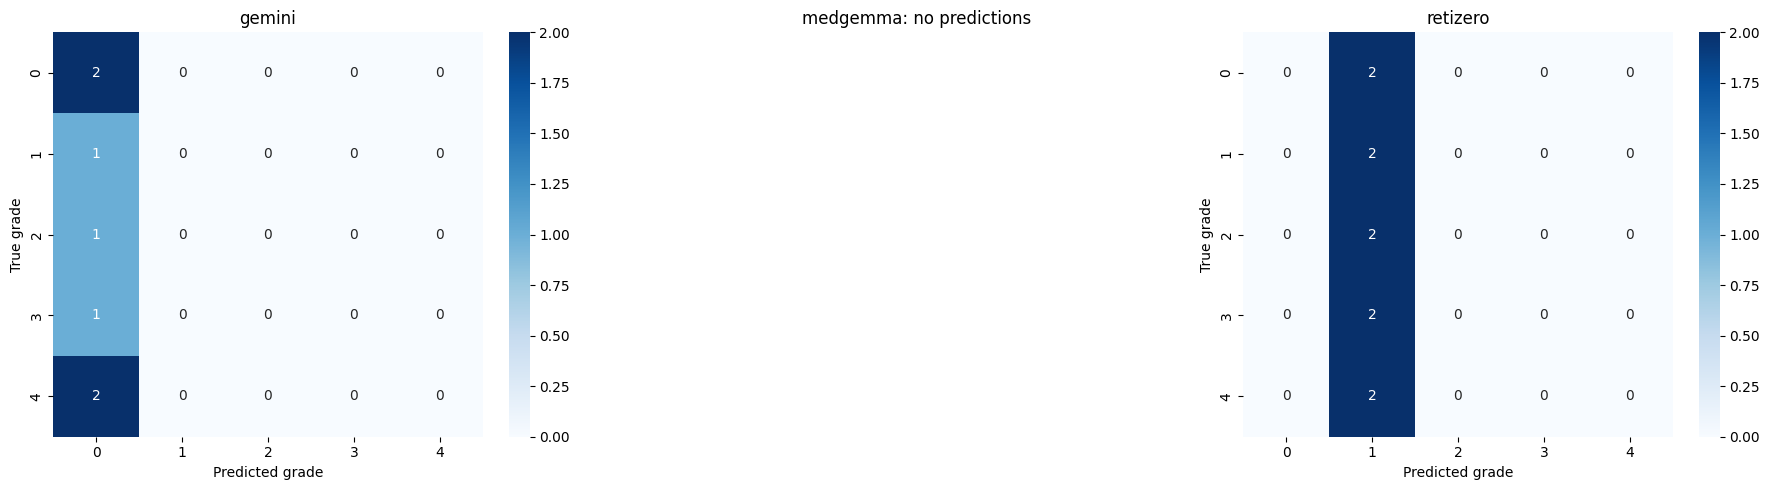

In [56]:
import seaborn as sns

# One confusion matrix per model, side by side, so grading errors (e.g. always confusing
# grade 2 and 3) are visible at a glance rather than buried in the summary metrics.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, model_col in zip(axes, MODELS):
    model_name = model_col.replace("_pred", "")
    valid = results_df.dropna(subset=[model_col])
    if len(valid) == 0:
        ax.set_title(f"{model_name}: no predictions")
        ax.axis("off")
        continue
    cm = confusion_matrix(valid["ground_truth"].astype(int), valid[model_col].astype(int), labels=[0, 1, 2, 3, 4])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=range(5), yticklabels=range(5))
    ax.set_title(model_name)
    ax.set_xlabel("Predicted grade")
    ax.set_ylabel("True grade")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrices.png", dpi=150)
plt.show()


## 10. Export a results table for the report

In [57]:
# Same numbers as metrics_summary.json, reshaped into a table (one row per model) and
# printed as Markdown so it can be pasted straight into reports/report_template.md.
summary_table = pd.DataFrame(metrics_summary).T
summary_table.to_csv(f"{RESULTS_DIR}/summary_table.csv")
print(summary_table.to_markdown())


|          |   n_scored |   n_total |   accuracy | accuracy_95ci   |   quadratic_weighted_kappa |   mean_absolute_error_grades | error                |
|:---------|-----------:|----------:|-----------:|:----------------|---------------------------:|-----------------------------:|:---------------------|
| gemini   |          7 |        10 |     0.2857 | [0.0, 0.7143]   |                          0 |                          2   | nan                  |
| medgemma |        nan |       nan |   nan      | nan             |                        nan |                        nan   | no valid predictions |
| retizero |         10 |        10 |     0.2    | [0.0, 0.5]      |                          0 |                          1.4 | nan                  |


## 11. Package and download results

Run this when you're done. It bundles every artifact the report needs (`predictions.csv`,
`metrics_summary.json`, `summary_table.csv`, `confusion_matrices.png`, plus the sample grid)
into one tarball and triggers a browser download. Extract it into the repo root so the
`results/` folder populates the report.


In [58]:
import tarfile

# Bundle everything the write-up needs into one file so there's a single download instead
# of pulling each artifact out of the Colab file browser individually.
tar_path = "/content/results.tar.gz"
with tarfile.open(tar_path, "w:gz") as tar:
    tar.add(RESULTS_DIR, arcname="results")
    tar.add("/content/sample_grid.png", arcname="sample_grid.png")

from google.colab import files
files.download(tar_path)  # triggers a browser download in Colab
print("Downloaded results.tar.gz -> extract into the repo root (creates results/)")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded results.tar.gz -> extract into the repo root (creates results/)


## 12. Notes and limitations (read before writing up results)

Quick recap for the write-up — see the README for the full version:

- **Ground truth is one grader's opinion, not an infallible reference** — published
  inter-ophthalmologist ICDR agreement sits at kappa 0.40-0.65. Frame conclusions accordingly.
- **Gemini is a generalist doing a specialist's task**; MedGemma and RetiZero were both
  medically pretrained. Say so rather than presenting three equivalent peers.
- **This notebook is structurally complete but not yet run end-to-end on a GPU** (no
  GPU/Kaggle access in the authoring environment) — the RetiZero wiring was checked
  line-by-line against its upstream source, but budget time for first-run surprises.
